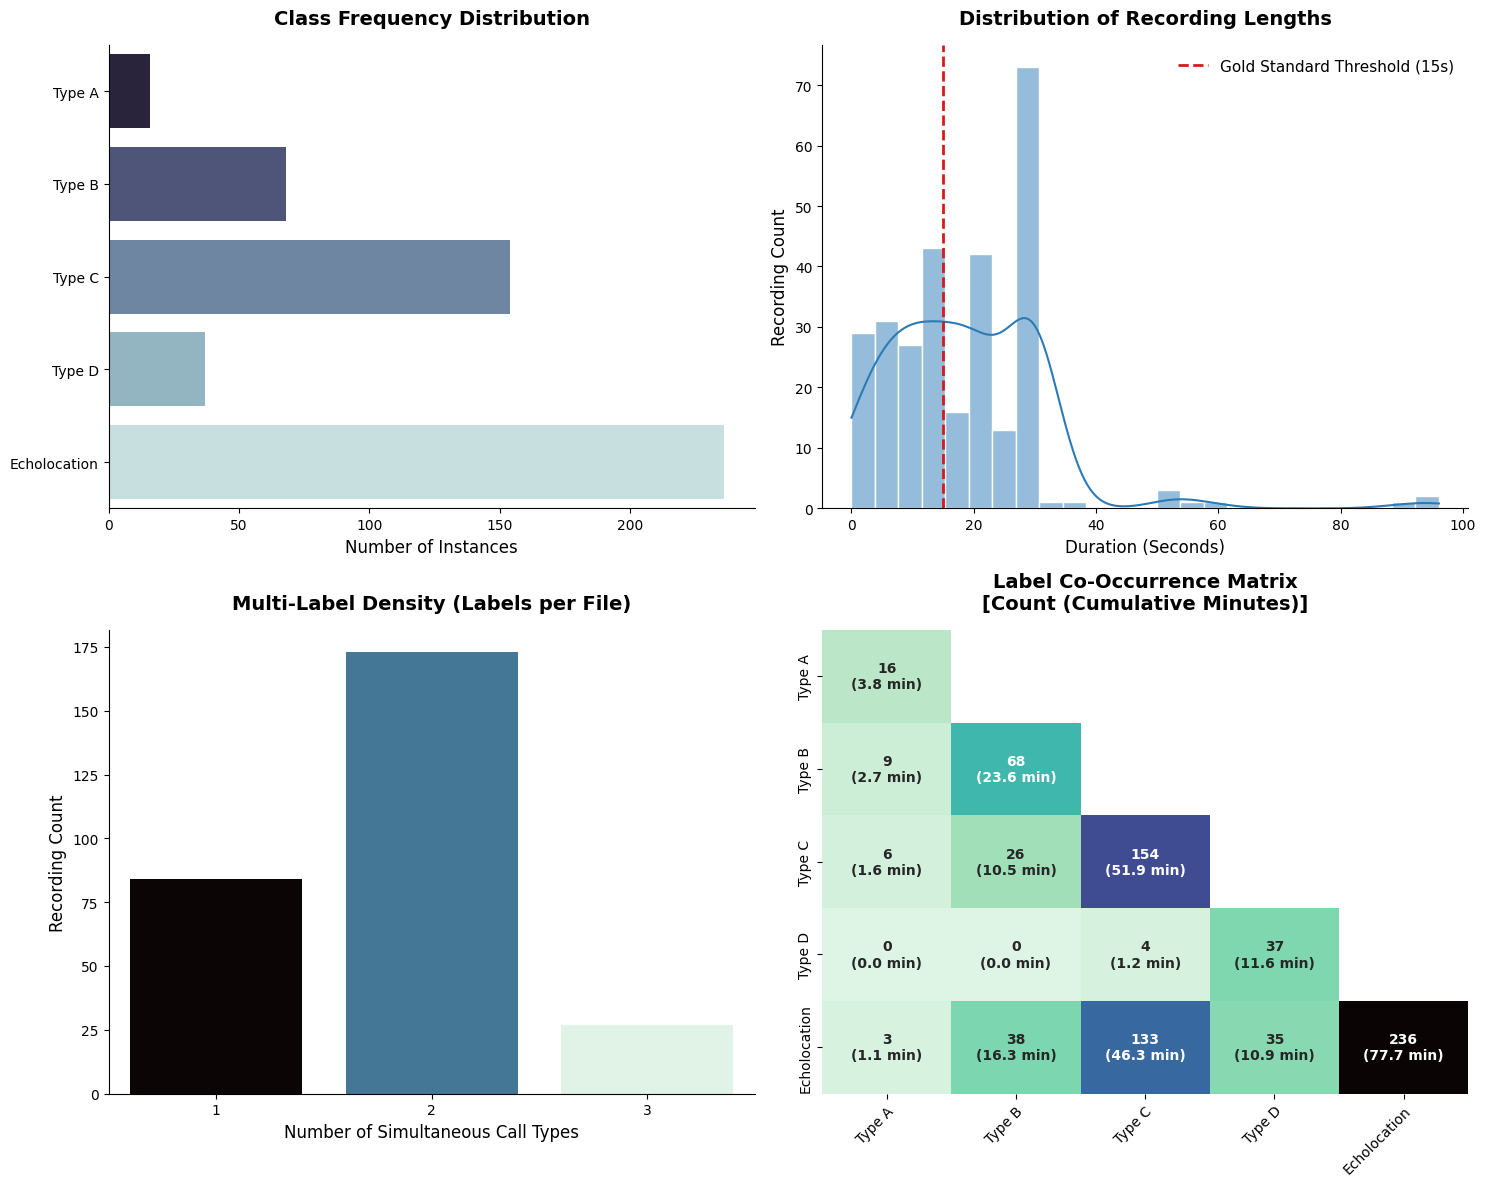


             DATASET SUMMARY STATISTICS            
Total Recordings : 284
Total Audio Time : 1.48 Hours (5,332.2 Seconds)
Mean File Length : 18.78 Seconds

     ACADEMIC MULTI-LABEL IMBALANCE METRICS       
Label Name      | Instance Count | IR_Lbl Score
--------------------------------------------------
Type A          | 16             | 14.7500
Type B          | 68             | 3.4706
Type C          | 154            | 1.5325
Type D          | 37             | 6.3784
Echolocation    | 236            | 1.0000
--------------------------------------------------
Global SCUMBLE Index: 0.0821


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Data and Set Core Framework Constants
df = pd.read_csv("final_metadata_len.csv")
label_cols = ['type_a', 'type_b', 'type_c', 'type_d', 'echo']
nice_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echolocation']

# Configure crisp, academic chart configurations
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# --- 2. Advanced Multi-Label Metric Calculations ---
counts = df[label_cols].sum()
max_class_count = counts.max()

# Imbalance Ratio per Label (IR_Lbl)
# IR_Lbl = Max_Label_Count / Current_Label_Count (1.0 means it's the majority class)
ir_lbl_dict = {col: max_class_count / counts[col] for col in label_cols}

# SCUMBLE Calculation per Instance
scumble_instances = []
for _, row in df[label_cols].iterrows():
    # Identify which labels are active (1) in this specific recording
    active_labels = [col for col in label_cols if row[col] == 1]
    
    if len(active_labels) <= 1:
        # SCUMBLE is 0 if there are no co-occurrences to evaluate
        scumble_instances.append(0.0)
    else:
        # Get the IR_Lbl values for all active labels in this file
        active_irs = [ir_lbl_dict[l] for l in active_labels]
        
        # Calculate Geometric and Arithmetic Mean of the active label IRs
        geo_mean = np.prod(active_irs) ** (1.0 / len(active_irs))
        ari_mean = np.mean(active_irs)
        
        # SCUMBLE_i = 1 - (Geometric Mean / Arithmetic Mean)
        scumble_i = 1.0 - (geo_mean / ari_mean)
        scumble_instances.append(scumble_i)

global_scumble = np.mean(scumble_instances)

# --- 3. Compute Co-occurrence Counts & Minute Durations ---
co_counts = df[label_cols].T @ df[label_cols]
# Compute total shared seconds across pairs, then convert to minutes
co_durations_sec = df[label_cols].T @ (df[label_cols].multiply(df['duration'], axis=0))
co_durations_min = co_durations_sec / 60.0

# Generate a matrix of custom text annotations for the heatmap cells
annot_labels = np.empty((len(label_cols), len(label_cols)), dtype=object)
for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        cnt = co_counts.iloc[i, j]
        mns = co_durations_min.iloc[i, j]
        annot_labels[i, j] = f"{int(cnt)}\n({mns:.1f} min)"

# --- 4. Plotting the Dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# Uniform palette scheme mapping clean corporate-ecological tones
bar_palette = sns.cubehelix_palette(n_colors=5, start=.2, rot=-.3, reverse=True)

# Plot 1: Total Occurrences per Class
sns.barplot(x=counts.values, y=nice_names, ax=axes[0, 0], palette=bar_palette, hue=nice_names, legend=False)
axes[0, 0].set_title('Class Frequency Distribution', pad=15, weight='bold')
axes[0, 0].set_xlabel('Number of Instances')
axes[0, 0].spines[['top', 'right']].set_visible(False)

# Plot 2: Recording Duration Profile
sns.histplot(df['duration'], bins=25, color='#2c7bb6', kde=True, ax=axes[0, 1], edgecolor='white')
axes[0, 1].axvline(15, color='#d7191c', linestyle='--', linewidth=2, label='Gold Standard Threshold (15s)')
axes[0, 1].set_title('Distribution of Recording Lengths', pad=15, weight='bold')
axes[0, 1].set_xlabel('Duration (Seconds)')
axes[0, 1].set_ylabel('Recording Count')
axes[0, 1].legend(frameon=True, facecolor='white', edgecolor='none')
axes[0, 1].spines[['top', 'right']].set_visible(False)

# Plot 3: Multi-label Density
df['num_labels'] = df[label_cols].sum(axis=1)
density = df['num_labels'].value_counts().sort_index()
sns.barplot(x=density.index.astype(int), y=density.values, ax=axes[1, 0], palette='mako', hue=density.index, legend=False)
axes[1, 0].set_title('Multi-Label Density (Labels per File)', pad=15, weight='bold')
axes[1, 0].set_xlabel('Number of Simultaneous Call Types')
axes[1, 0].set_ylabel('Recording Count')
axes[1, 0].spines[['top', 'right']].set_visible(False)

# Plot 4: Professional Co-occurrence Matrix with Custom Strings
# Masking upper triangle for layout scannability
mask = np.triu(np.ones_like(co_counts, dtype=bool), k=1)
sns.heatmap(
    co_counts, 
    annot=annot_labels, 
    fmt="", 
    cmap='mako_r', 
    mask=mask, 
    ax=axes[1, 1],
    cbar=False,  # Raw counts text is definitive, color bar is redundant here
    xticklabels=nice_names, 
    yticklabels=nice_names,
    annot_kws={'size': 10, 'weight': 'bold'}
)
axes[1, 1].set_title('Label Co-Occurrence Matrix\n[Count (Cumulative Minutes)]', pad=15, weight='bold')
plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

plt.tight_layout()
plt.show()

# --- 5. Clean Structured Markdown Console Reports ---
print("\n" + "="*50)
print("             DATASET SUMMARY STATISTICS            ")
print("="*50)
print(f"Total Recordings : {len(df):,}")
print(f"Total Audio Time : {df['duration'].sum() / 3600:.2f} Hours ({df['duration'].sum():,.1f} Seconds)")
print(f"Mean File Length : {df['duration'].mean():.2f} Seconds")

print("\n" + "="*50)
print("     ACADEMIC MULTI-LABEL IMBALANCE METRICS       ")
print("="*50)
print(f"{'Label Name':<15} | {'Instance Count':<14} | {'IR_Lbl Score':<12}")
print("-" * 50)
for col, name in zip(label_cols, nice_names):
    print(f"{name:<15} | {int(counts[col]):<14,} | {ir_lbl_dict[col]:.4f}")
print("-" * 50)
print(f"Global SCUMBLE Index: {global_scumble:.4f}")
print("="*50)

--- DATASET OVERVIEW ---
Total Recordings: 284
Total Audio:      1.48 hours ($5332$ seconds)
Average Length:   18.78 seconds
-------------------------


C:\Users\anast\AppData\Local\Temp\ipykernel_19480\3730766104.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')
C:\Users\anast\AppData\Local\Temp\ipykernel_19480\3730766104.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_density.index.astype(int), y=label_density.values, palette='magma')


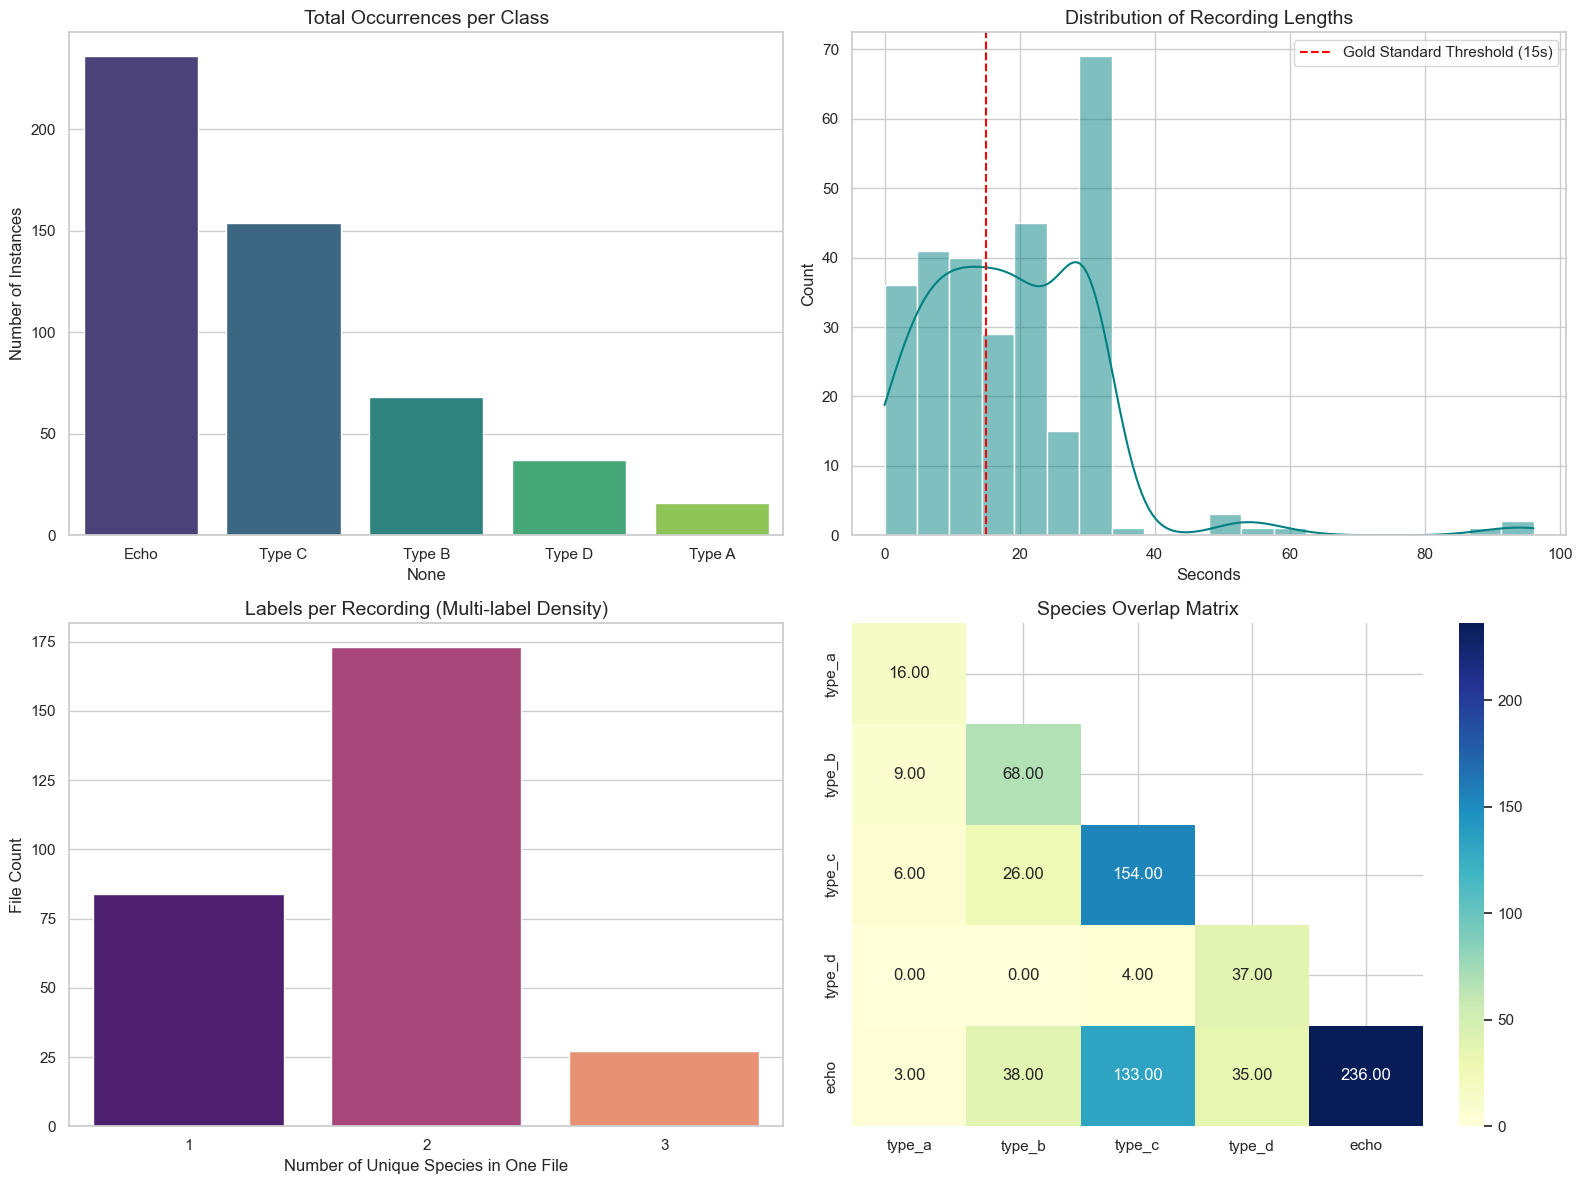


--- CLASS IMBALANCE ---
Majority Class: echo (236 samples)
Minority Class: type_a (16 samples)
Imbalance Ratio: 1:14.8


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your metadata
df = pd.read_csv("final_metadata_len.csv")

# Define labels
label_cols = ['type_a', 'type_b', 'type_c', 'type_d', 'echo']
nice_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echolocation']

# --- 1. Summary Statistics ---
total_files = len(df)
total_seconds = df['duration'].sum()
total_hours = total_seconds / 3600
avg_duration = df['duration'].mean()

print(f"--- DATASET OVERVIEW ---")
print(f"Total Recordings: {total_files}")
print(f"Total Audio:      {total_hours:.2f} hours (${total_seconds:.0f}$ seconds)")
print(f"Average Length:   {avg_duration:.2f} seconds")
print("-" * 25)

# --- 2. Visualization Code ---
plt.figure(figsize=(16, 12))

# Subplot 1: Class Distribution (Total instances of each bat)
plt.subplot(2, 2, 1)
counts = df[label_cols].sum().sort_values(ascending=False)
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Total Occurrences per Class', fontsize=14)
plt.ylabel('Number of Instances')
plt.xticks(ticks=range(5), labels=[n.replace('_', ' ').title() for n in counts.index])

# Subplot 2: Duration Distribution (The "Gold" vs "Long" split)
plt.subplot(2, 2, 2)
sns.histplot(df['duration'], bins=20, color='teal', kde=True)
plt.axvline(15, color='red', linestyle='--', label='Gold Standard Threshold (15s)')
plt.title('Distribution of Recording Lengths', fontsize=14)
plt.xlabel('Seconds')
plt.legend()

# Subplot 3: Multi-label Density (How many bats per file?)
plt.subplot(2, 2, 3)
df['num_labels'] = df[label_cols].sum(axis=1)
label_density = df['num_labels'].value_counts().sort_index()
sns.barplot(x=label_density.index.astype(int), y=label_density.values, palette='magma')
plt.title('Labels per Recording (Multi-label Density)', fontsize=14)
plt.xlabel('Number of Unique Species in One File')
plt.ylabel('File Count')

# Subplot 4: Co-occurrence Heatmap (Who hangs out with whom?)
plt.subplot(2, 2, 4)
co_occurrence = df[label_cols].T @ df[label_cols]
mask = np.triu(np.ones_like(co_occurrence, dtype=bool), k=1)
sns.heatmap(co_occurrence, annot=True, fmt='.2f', cmap='YlGnBu', mask=mask)
plt.title('Species Overlap Matrix', fontsize=14)

#plt.subplot(2, 2, 4)
#co_occurrence = df[label_cols].T @ df[label_cols]
## Mask the diagonal for better visibility of overlaps
#mask = np.eye(co_occurrence.shape[0], dtype=bool)
#sns.heatmap(co_occurrence, annot=True, fmt='g', cmap='YlGnBu', 
#            xticklabels=nice_names, yticklabels=nice_names)
#plt.title('Species Overlap Matrix', fontsize=14)

plt.tight_layout()
plt.show()

# --- 3. Print Imbalance Ratio ---
print(f"\n--- CLASS IMBALANCE ---")
max_class = counts.max()
min_class = counts.min()
print(f"Majority Class: {counts.index[0]} ({max_class} samples)")
print(f"Minority Class: {counts.index[-1]} ({min_class} samples)")
print(f"Imbalance Ratio: 1:{max_class/min_class:.1f}")

C:\Users\anast\AppData\Local\Temp\ipykernel_19480\134825724.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[n.replace('_', ' ').title() for n in hours_series.index],
C:\Users\anast\AppData\Local\Temp\ipykernel_19480\134825724.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hours_by_complexity.index.astype(int), y=hours_by_complexity.values, palette='magma')


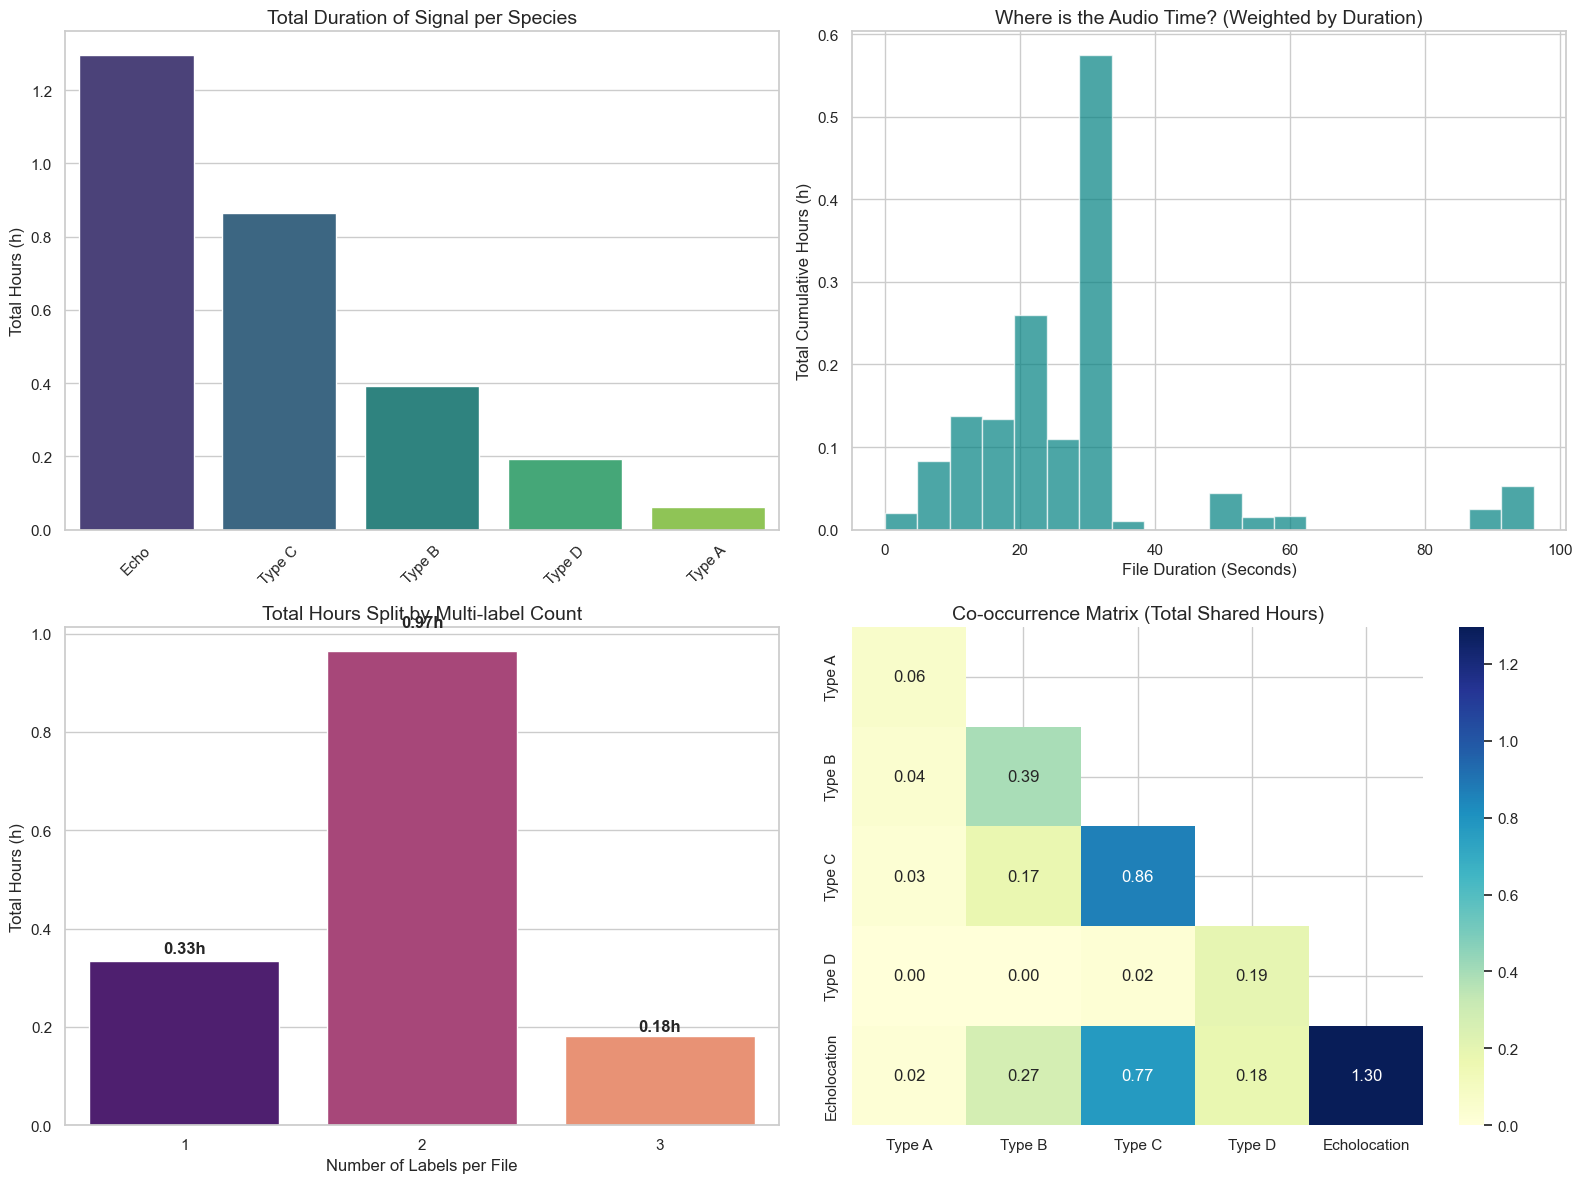

Verified Total Dataset Duration: 1.48 hours


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load metadata
df = pd.read_csv("final_metadata_len.csv")

# Define labels
label_cols = ['type_a', 'type_b', 'type_c', 'type_d', 'echo']
nice_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echolocation']

# --- CALCULATIONS ---

# 1. Total Hours per Label (Summing durations)
# We sum the duration for every file where the label is 1
hours_per_label = {col: df[df[col] == 1]['duration'].sum() / 3600 for col in label_cols}
hours_series = pd.Series(hours_per_label).sort_values(ascending=False)

# 2. Multi-label Hours (Total time spent in multi-species contexts)
df['num_labels'] = df[label_cols].sum(axis=1)
hours_by_complexity = df.groupby('num_labels')['duration'].sum() / 3600

# 3. Time-based Co-occurrence (How many hours do species overlap?)
n = len(label_cols)
overlap_hours = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        # Sum duration where BOTH labels are 1
        mask = (df[label_cols[i]] == 1) & (df[label_cols[j]] == 1)
        overlap_hours[i, j] = df[mask]['duration'].sum() / 3600
overlap_df = pd.DataFrame(overlap_hours, index=nice_names, columns=nice_names)

# --- PLOTTING ---
plt.figure(figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Subplot 1: Duration per Species
plt.subplot(2, 2, 1)
sns.barplot(x=[n.replace('_', ' ').title() for n in hours_series.index], 
            y=hours_series.values, palette='viridis')
plt.title('Total Duration of Signal per Species', fontsize=14)
plt.ylabel('Total Hours (h)')
plt.xticks(rotation=45)

# Subplot 2: Total Hours per File Length (Weighted Histogram)
# This uses the weights parameter to ensure the Y-axis is Total Hours, not Count
plt.subplot(2, 2, 2)
plt.hist(df['duration'], bins=20, weights=df['duration'] / 3600, color='teal', alpha=0.7)
plt.title('Where is the Audio Time? (Weighted by Duration)', fontsize=14)
plt.xlabel('File Duration (Seconds)')
plt.ylabel('Total Cumulative Hours (h)')

# Subplot 3: Time Spent in Multi-label Files
plt.subplot(2, 2, 3)
sns.barplot(x=hours_by_complexity.index.astype(int), y=hours_by_complexity.values, palette='magma')
plt.title('Total Hours Split by Multi-label Count', fontsize=14)
plt.xlabel('Number of Labels per File')
plt.ylabel('Total Hours (h)')
for i, v in enumerate(hours_by_complexity.values):
    plt.text(i, v + (v * 0.05), f"{v:.2f}h", ha='center', fontweight='bold')

# Subplot 4: Overlap Matrix (Time-based)
plt.subplot(2, 2, 4)
mask = np.triu(np.ones_like(overlap_df, dtype=bool), k=1)
sns.heatmap(overlap_df, annot=True, fmt='.2f', cmap='YlGnBu', mask=mask)
plt.title('Co-occurrence Matrix (Total Shared Hours)', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Verified Total Dataset Duration: {df['duration'].sum()/3600:.2f} hours")